In [166]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [167]:
df = pd.read_csv("../../Data/final/environment_data.csv")

In [168]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2',
       'Green_Space', 'Temperature_mean', 'Temperature_max', 'Humidity',
       'Wind_speed', 'Pressure', 'Electricity Consumption', 'isWeekend',
       'Season'],
      dtype='object')

In [ ]:
corr = df.corr(numeric_only=True)

corr['PM2.5'].sort_values(ascending=False)

PM2.5                      1.000000
PM10                       0.899929
NO2                        0.585450
SO2                        0.573467
Temperature_mean           0.533332
Temperature_max            0.507370
CO                         0.503125
O3                         0.260652
Pressure                   0.116458
isWeekend                 -0.027864
Electricity Consumption   -0.049888
Wind_speed                -0.142282
Humidity                  -0.393499
Green_Space               -0.558114
Name: PM2.5, dtype: float64

In [170]:
df.drop(["Temperature_max","Electricity Consumption","isWeekend","Date"],axis=1,inplace=True)
df.rename(columns={"pm2.5":"Target"},inplace=True)

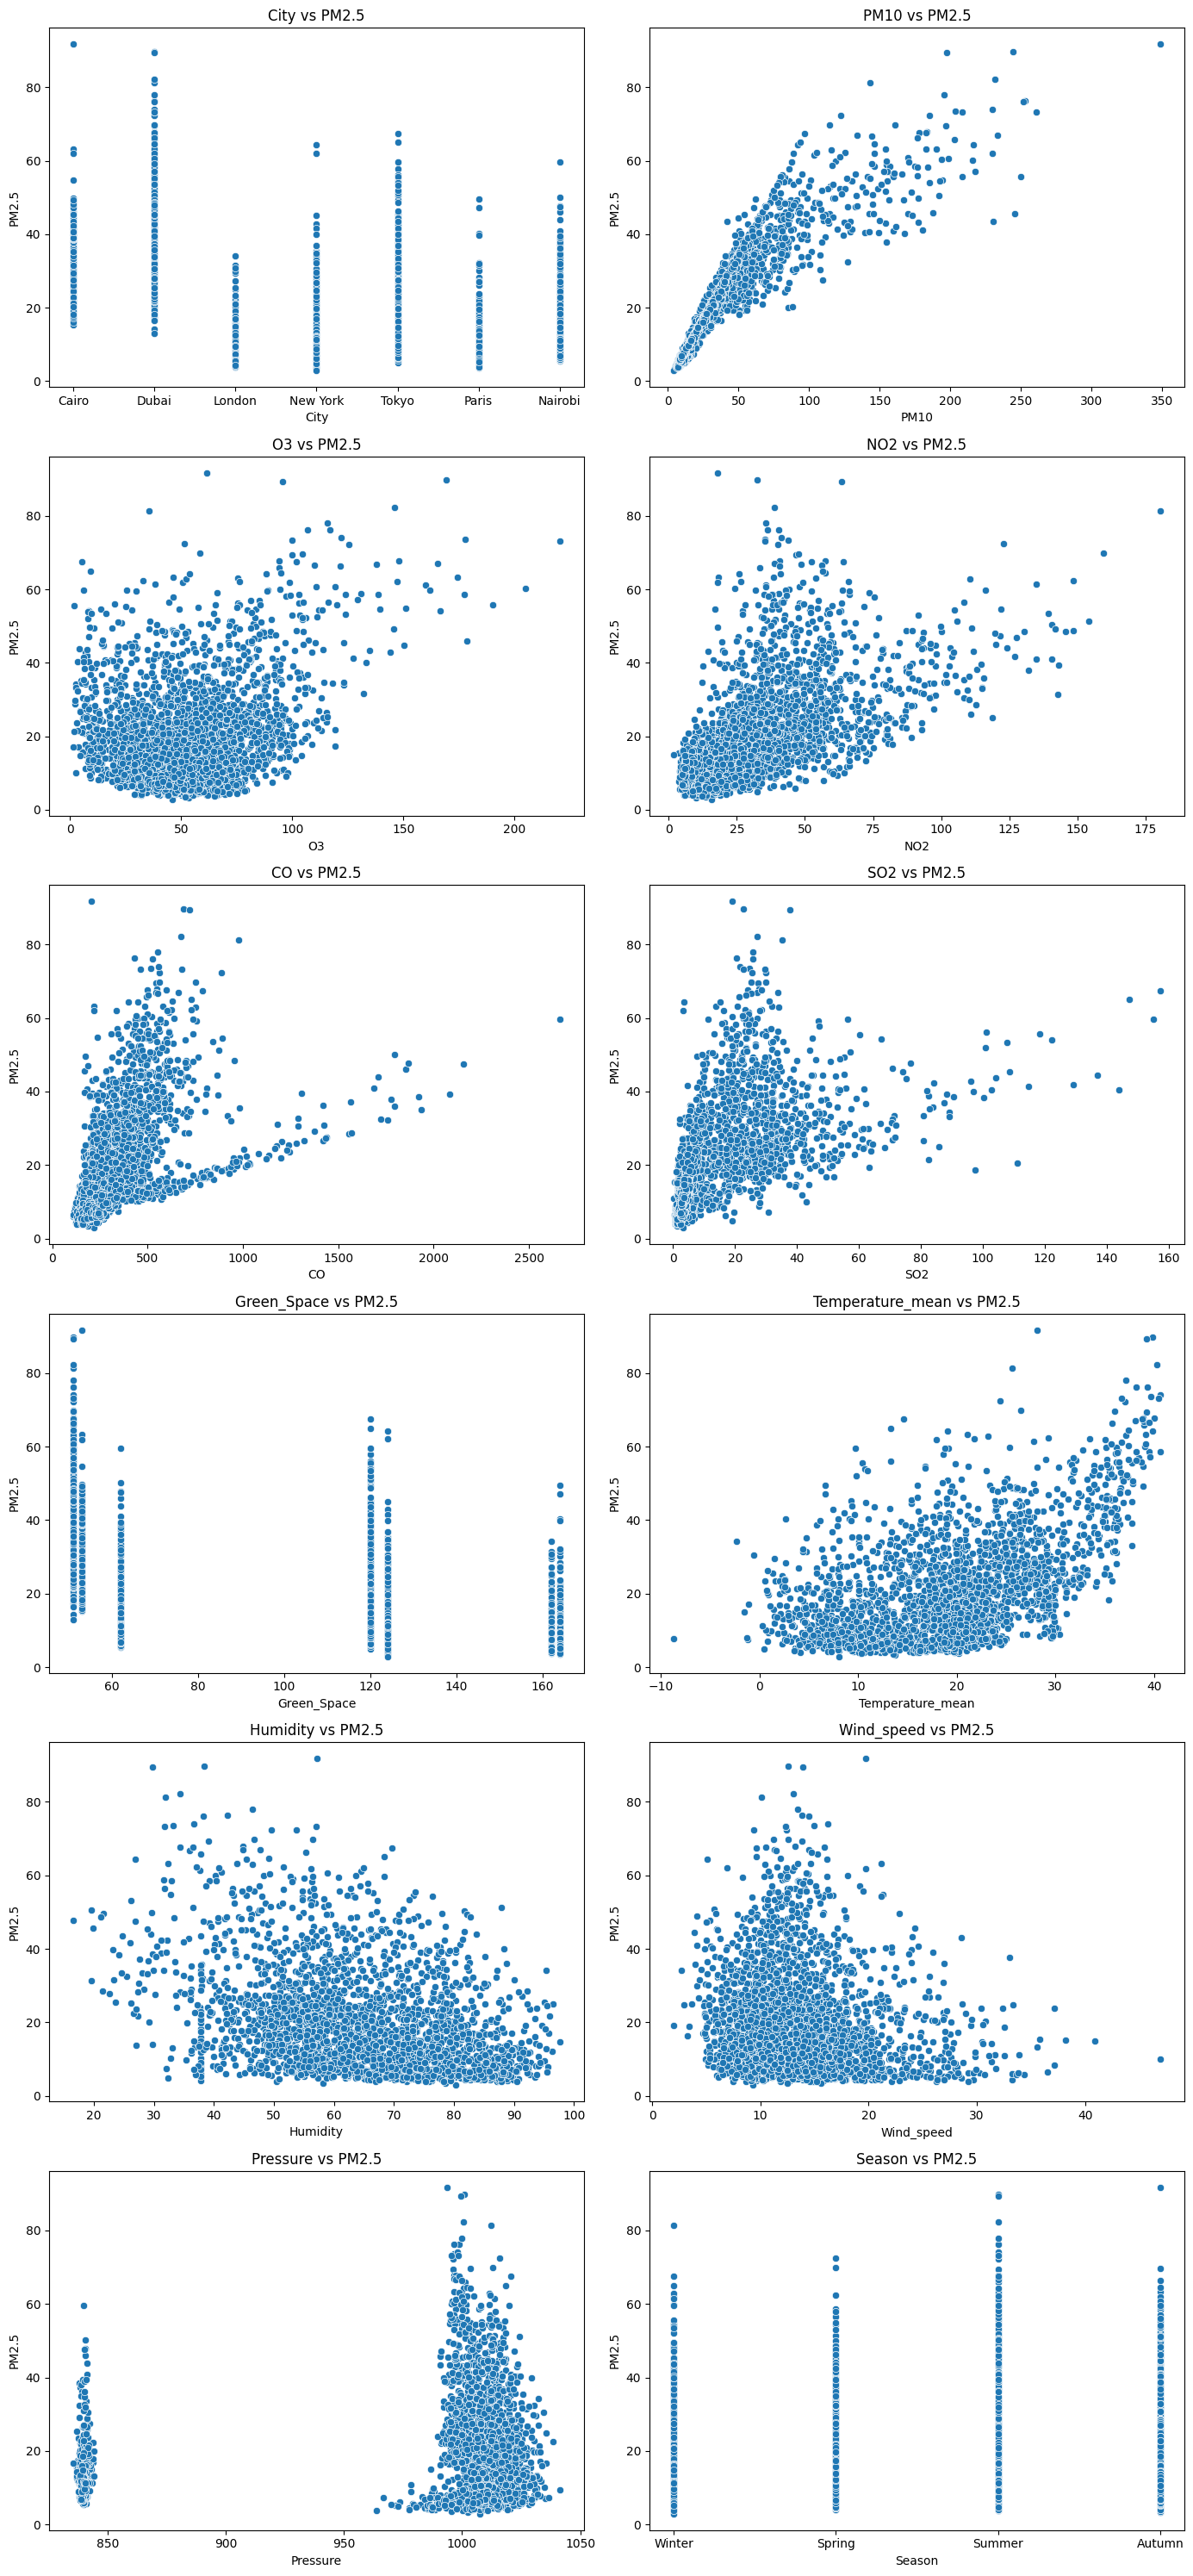

In [171]:


import math

target = 'PM2.5'

features = [col for col in df.columns if col != target]

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        x=df[feature],
        y=df[target],
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Higher temperatures are associated with increased PM2.5 concentrations.

In [172]:
df.columns

Index(['City', 'PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2', 'Green_Space',
       'Temperature_mean', 'Humidity', 'Wind_speed', 'Pressure', 'Season'],
      dtype='object')

In [179]:
df.rename(columns={"PM2.5":"Target"},inplace=True)

In [ ]:
from sklearn import pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


cat_cols = ["City", "Season"]
num_cols = [
    "PM10",
    "O3",
    "NO2",
    "CO",
    "SO2",
    "Green_Space",
    "Temperature_mean",
    "Humidity",
    "Wind_speed",
    "Pressure",
]
X=df.drop(columns=["Target"])
Y=df["Target"]
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 8, 10],
    'model__min_samples_split':[5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4]
}

preprocessor=ColumnTransformer([
    
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(handle_unknown='ignore'),cat_cols)
]
    
)
pipeline=Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
]
)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    error_score='raise',
    return_train_score=True
)

grid_search.fit(X, Y)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nValidation R2 Score:")
print(round(grid_search.best_score_, 4))

print("\nTrain R2 Score:")
print(round(np.max(grid_search.cv_results_['mean_train_score']), 4))

print("\nOverfitting Gap:")
print(round(
    np.max(grid_search.cv_results_['mean_train_score']) - grid_search.best_score_,
    4
))

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Validation R2 Score:
0.9062

Train R2 Score:
0.9915

Overfitting Gap:
0.0852


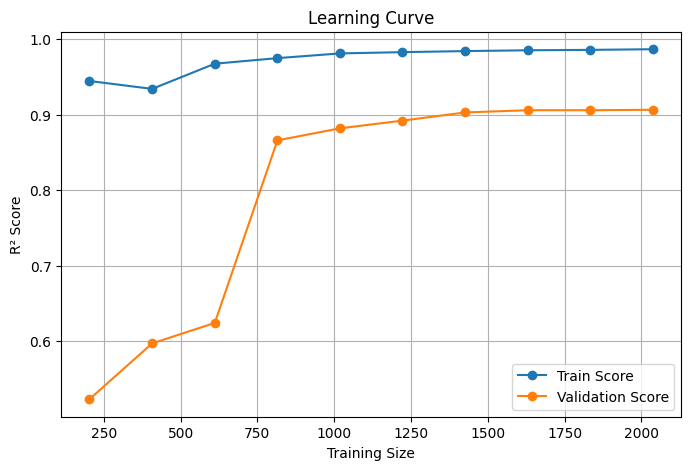

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    Y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label='Train Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")

plt.legend()
plt.grid()

plt.show()

The learning curve shows that the model learns effectively as the training data increases. The validation R² score improves significantly with larger training sizes and stabilizes around 0.90, indicating strong generalization performance. Although the training score remains consistently higher than the validation score, suggesting slight overfitting, the gap is moderate and the model maintains stable predictive performance overall.

In [200]:
import joblib

joblib.dump(best_model,"../../models/pm25_model_pollution.pkl")

['../../models/pm25_model_pollution.pkl']